# Pràctica 1: Resolem un problema de classificació

## Objectius

Els objectius d’aquesta pràctica són:

* Aplicar els coneixements adquirits sobre classificació, tècniques d’emplenament de valors perduts i validació creuada.

* Comparar diferents models de classificació.

* Realitzar la cerca d’hiperparàmetres.

* Entendre i implementar la validació creuada.

* Analitzar detalladament els resultats obtinguts durant l’entrenament dels diferents models.

Aquesta pràctica és prèvia al cas Kaggle que realitzareu durant la segona part de l’assignatura. En aquesta primera fase les preguntes estan definides, però us ha de servir d’aprenentatge per saber com estructurar un projecte d’aprenentatge automàtic, ja que en el cas Kaggle no tindreu les preguntes pautades.

## Bases de dades
En aquesta pràctica farem servir la base de dades del *Titanic*. L’atribut a predir és *Survived*, que indica si cada passatger va sobreviure o no.

[Enllaç a les dades](https://www.kaggle.com/c/titanic/data)

## Treball en grup

La pràctica es durà a terme en grups de 2 o 3 persones. En casos excepcionals i degudament justificats, es podrà realitzar de manera individual.

## Seguiment i entrega de la pràctica

A la Pràctica 1 es proposen diverses tasques per fer una comparació adequada dels resultats obtinguts amb diferents mètodes de classificació aplicats a una mateixa base de dades.

Es realitzaran sessions de seguiment del treball, orientades a resoldre dubtes sobre les dades, aclarir els objectius de cada apartat de l’enunciat i comentar els resultats obtinguts durant l’anàlisi. És molt recomanable assistir-hi amb el treball ja avançat per tal de poder aprofitar millor la sessió.

Pel que fa a l’entrega, caldrà lliurar a través de Caronte el següent:

1. *Memòria* en format PDF o en la mateixa notebook, explicant els resultats obtinguts sobre la base de dades i incloent el codi en Python corresponent. Aquesta nota serà la mateixa per a tots els membres del grup. (9 punts)

2. *Presentació* amb els resultats (màxim 4 minuts). Aquesta nota serà individual. (1 punt)

*Nota*: En cas d’entregar la memòria en format PDF, cal adjuntar el codi en Python per separat. Si s’entrega en format notebook, aquest mateix document ja servirà com a codi.


# Continguts que s’avaluaran en la pràctica

1. **EDA (Exploratory Data Analysis)** – 1 punt

* Anàlisi de la mida i tipologia de les dades (0.25 pts)

* Primera valoració de correlacions (0.5 pts)

* Anàlisi de l’atribut target (0.25 pts)

2. **Preprocessament** – 2 punts

* Eliminació de valors nuls (0.5 pts)

* Codificació de variables categòriques (0.75 pts)

* Altres (PCA, normalització, etc.) (0.75 pts)

3. **Selecció de mètriques** – 1.5 punts

* Selecció de la mètrica més adequada pel problema (0.75 pts)

* Visualització de corbes ROC/AUC (0.75 pts)

4. **Selecció de models amb validació creuada** – 4 punts

* Selecció del millor model (2 pts)

* Cerca d’hiperparàmetres (2 pts)

5. **Anàlisi final** – 1.5 punts

Cal tenir en compte que les puntuacions dins de cada apartat són orientatives. La pràctica està estructurada a partir d’un seguit de preguntes guia en cada secció, relacionades amb els continguts avaluables. **No cal respondre-les totes**: el seu objectiu és ajudar-vos a reflexionar i aprofundir en els aspectes clau de cada apartat. Tot i així, és recomanable llegir-les prèviament i tenir-les en compte durant el desenvolupament de la pràctica.

**IMPORTANT**: El criteri principal d’avaluació serà la capacitat de mantenir una narrativa coherent a mesura que es presenten els resultats. No es penalitzarà deixar alguna pregunta sense respondre, sempre que el procés seguit i les conclusions extretes a partir dels resultats siguin consistents i ben fonamentats.

### 1. EDA (*Exploratory Data Analysis*) – **1 punt**

Abans de començar, és fonamental analitzar la base de dades assignada.  

**Preguntes:**  
-  1.Quants atributs té la base de dades?  
Té un total de 12 atributs: PassengerID, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin i Embarked.

-  2.Quin tipus d’atributs hi ha? (numèrics, temporals, categòrics, binaris, ...)  
PassengerID (Categòric), Survived (Binari), Pclass (Categòric), Name (Textual), Sex (Binari), Age (Numèric), SibSp (Numèric), Parch (Numèric), Ticket (Categòric),Fare (Numèric), Cabin (Categòric), Embarked (Categòric)

-  3.Com és el *target*? Quantes categories diferents té?  
L'atribut target és l'atribut “Survived”, que és de tipus binari i, consecuentment, té dos possibles valors:
0 si no va sobreviure i 1 si va sobreviure.

-  4.Hi ha valors nuls (*NaNs*) a les dades?  Si, hi han alguns, concretament en les columnes Age, Cabin i Embarked. Es pot veure veient els counts dels diferents camps.

-  5.Es poden observar correlacions entre les variables explicatives (*X*) i la variable objectiu (*y*)? Si. Per mostrar-ho hem fet el codi d'aquí sota. Es pot comprovar veient com la mitjana d'algunes categories, com el sexe o el cost, es molt diferent entre els dos sub-dataframes.

-  6.Les etiquetes estan balancejades? (és a dir, hi ha una distribució similar entre categories?). Creus que la seva distribució pot afectar la classificació? Això es pot saber relacionant les medianes amb les mitjanes de alguns camps no categòrics, i mirant els valors dels quartils. Podem veure que algunes etiquetes com els preus no ho estàn, i això pot afectar bastant a la classificació i predicció del atribut objectiu.

In [1]:
#Llibreries
import pandas as pd
from pandas.api.types import is_numeric_dtype
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.metrics import accuracy_score, mean_absolute_error, classification_report, f1_score, accuracy_score, precision_recall_curve, auc, roc_curve, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import seaborn as sns

from sklearn.model_selection import GridSearchCV


In [2]:
#1-Cantitat de atributs. (quants atributs té la base de dades?)
train = pd.read_csv('train.csv')

print("Nombre d'atributs:", len(train.columns))


Nombre d'atributs: 12


In [3]:
#5-Visual assistant required to answer 1. EDA questions. (correlacions entre les variables explicatives)
train = pd.read_csv('train.csv')
print("Print inicial:")
print(train.describe(include='all'))

numeric_features = train.select_dtypes(np.number).keys()
non_numeric = [k for k in train.keys() if k not in numeric_features]

for col in non_numeric:
    train[col] = LabelEncoder().fit_transform(train[col])

target = 'Survived'
trains = train[train[target] == 1]
trainn = train[train[target] == 0]

print(f"\n\nAll data: {train.describe()}\n")
print(f"({target}): {trains.describe()}\n")
print(f"(Not {target}): {trainn.describe()}\n")

threshold = 0.5
correlation_categories = []
print(f"Likely correlationed to ({target}):")
for c in train.columns:
    if(abs(1-(trains[c].mean()/trainn[c].mean())) > threshold and c != target):
        correlation_categories.append(c)

print(correlation_categories)

Print inicial:
        PassengerId    Survived      Pclass                     Name   Sex  \
count    891.000000  891.000000  891.000000                      891   891   
unique          NaN         NaN         NaN                      891     2   
top             NaN         NaN         NaN  Braund, Mr. Owen Harris  male   
freq            NaN         NaN         NaN                        1   577   
mean     446.000000    0.383838    2.308642                      NaN   NaN   
std      257.353842    0.486592    0.836071                      NaN   NaN   
min        1.000000    0.000000    1.000000                      NaN   NaN   
25%      223.500000    0.000000    2.000000                      NaN   NaN   
50%      446.000000    0.000000    3.000000                      NaN   NaN   
75%      668.500000    1.000000    3.000000                      NaN   NaN   
max      891.000000    1.000000    3.000000                      NaN   NaN   

               Age       SibSp       Parch  Tick

C:\Users\jempa\AppData\Local\Temp\ipykernel_19796\69455998.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  if(abs(1-(trains[c].mean()/trainn[c].mean())) > threshold and c != target):


### 2. Preprocessament (*normalització, tractament d’outliers, selecció de variables...*) – **2 punts**

Un cop conegudes les dades disponibles, cal preparar-les per als algoritmes d’aprenentatge. Segons la tipologia de dades, es poden filtrar atributs, aplicar reductors de dimensionalitat, codificar categories textuals en valors numèrics, normalitzar, o bé detectar i eliminar outliers.

Consulteu la documentació de scikit-learn sobre preprocessament per explorar les diferents opcions que ofereix.

Preguntes:

- Les dades estan normalitzades? Caldria fer-ho?

No, no estan normalitzades (escales completament diferents). Sí que és necessari normalitzar-ho, per a utilitzar les dades numèriques sense que els valors més elevats ofusquin els valors més petits. En aquest cas, caldria normalitzar fare i age, ja que són les úniques variables numèriques del dataset.

- En cas de normalitzar, quin tipus de normalització seria més adient per a les vostres dades?

Hi ha 3 formes de normalitzar les dades: StandardScaler (distribució normal), MinMaxScaler (rang de dades [0-1]) i RobustScaler (per treballar amb valors de diferents dimensions). Utilitzarem RobustScaler ja que és el tipus de normalització que deixa els valors més equitatius, com es pot comprovar amb el codi d'aquí sota.

- Hi ha moltes dades sense informació (NaNs)? Tingueu en compte que alguns mètodes no les toleren durant l’aprenentatge.

Com hem vist en l'exercici 1, podem trobar més de 200 valors NaNs en la columna d'edats, i alguns en Cabin i Embarked.

- Com afecta la classificació si les filtreu?

Perdríem una quarta part de les dades, el que comportaria molts altres problemes com una pèrdua en la precisió del model o la possibilitat de que s'esbiaixi el dataset.

- I si les reompliu? Com ho faríeu?

Mantendríem totes les mostres de dades. Per omplir els NaNs, podríem utilitzar la mediana de les variables numèriques (per reduir l'impacte dels outliers) i la moda/valors més freqüent per a les categòriques.

- Hi ha dades categòriques? Quina seria la codificació més adequada?

Si, com hem vist a l'exercici 1, hi han dades categòriques, com poden ser PClass, sex, etc. Aquestes poden ser codificades de diferents maneres, ajustant-se al que signifiquen. Per exemple la categoria sex, es podria utilitzar un labelEncoder, on male=0 i female=1. La PClass ja està codificada en nombres, per tant, no fa falta fer cap canvi. 
Pel contrari, hi han altres dades que optarem per eliminar ja que seràn dificils de codificar i no aporten res, com els noms, o que tenen una correlació alta amb altres, com Cabin, que té una correlació molt alta amb Pclass.

- Es poden extreure atributs addicionals a partir de les variables categòriques (per exemple, aplicant alguna regla sobre el text)?

Sí, es podria extreure informació. Per exemple, es podria considerar el nombre de cabines que ha comprat cada passatger, fent la longitud del split del camp. També es podría classificar en funció de la localització de les cabines en el vaixell.

- Caldria aplicar PCA? Quins beneficis o inconvenients tindria?

Sí, es podria aplicar PCA. Es simplificaria el problema i es reduiria la dimensionalitat, el temps d'execució i, possiblement, el soroll. Tot i això, es podria reduir bastant la variança de les mostres, el que perjudicaria al seu clustering i, per tant, a la precisió dels algorismes.

- Seria útil aplicar alguna tècnica de selecció de features? Ho trobeu necessari?

Sí, es podria aplicar alguna tècnica de selecció de features i pot ser útil per saber quines categories són més importants. Per una banda, podem escollir o descartar manualment categories, com poden ser Nom i PassengerID, ja que aquestes no aporten cap informació útil. 
Una tècnica automàtica pot ser el SequencialFeature Selector. Va afegint categories fins a arribar a un punt on no augmenta més, només agafant les categories que han millorat els resultats. En aquest problema, hem decidit no utilitzar cap selector ja que tampoc hi han tantes categories. Això si, descartarem algunes manualment, com ara el Nom i el PassengerID. També descartarem Cabin i Ticket ja que creiem que el primer camp té un percentatge massa alt de Nans per garantir bons resultats, i el segon un rang massa gran de valors únics. Això es pot veure al primer describe del exercici anterior.

- Es podrien aplicar PolynomialFeatures per millorar la classificació? En quins models tindria sentit fer-ho?



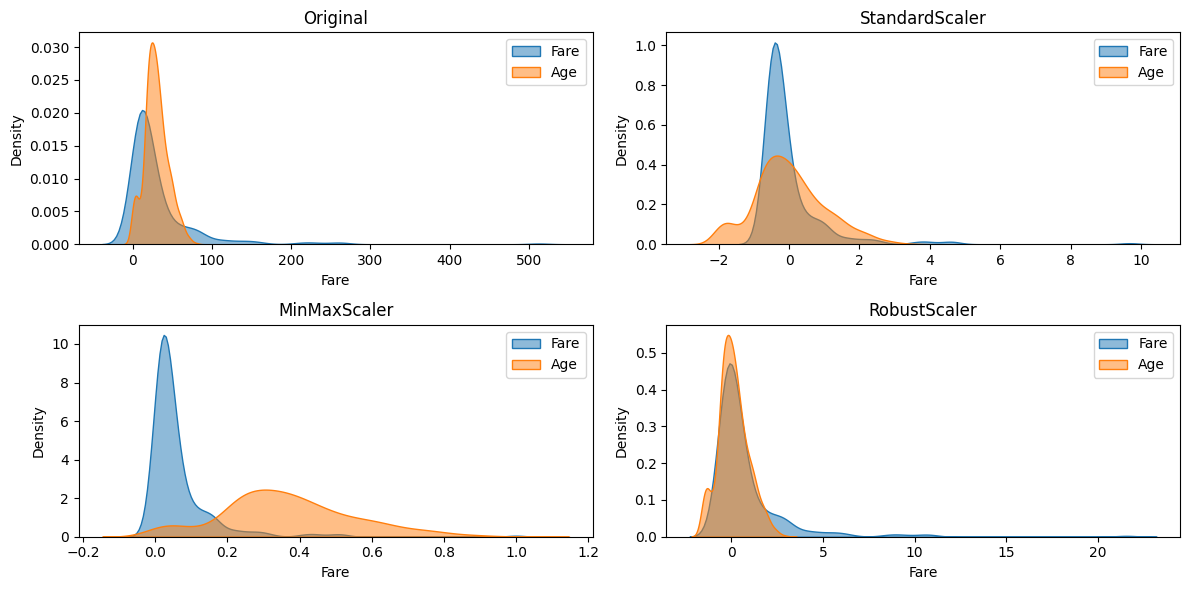

In [4]:
#Comparación de diferentes técnicas de normalización y estandarización
# Cargamos el dataset del Titanic
titanic = pd.read_csv("train.csv")

# Variables numericas con rangos muy diferentes
data = titanic[['Age', 'Fare']]

# Escaladores
scalers = {
    "Original": data,
    "StandardScaler": pd.DataFrame(StandardScaler().fit_transform(data), columns=data.columns),
    "MinMaxScaler": pd.DataFrame(MinMaxScaler().fit_transform(data), columns=data.columns),
    "RobustScaler": pd.DataFrame(RobustScaler().fit_transform(data), columns=data.columns),
}

# Visualización comparativa
plt.figure(figsize=(12, 6))

for i, (name, scaled) in enumerate(scalers.items(), 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(scaled['Fare'], fill=True, label='Fare', alpha=0.5)
    sns.kdeplot(scaled['Age'], fill=True, label='Age', alpha=0.5)
    plt.title(name)
    plt.legend()

plt.tight_layout()
plt.show()

### 3. Selecció de mètriques – **1.5 punts**

En aquest apartat ens centrarem en les mètriques de classificació ([documentació](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)).  

Per començar, entreneu una **regressió logística** (no cal separar *train-test*). A partir d’aquesta, genereu una sèrie de funcions per analitzar els resultats. Aquestes funcions serviran més endavant.  

També caldrà triar la mètrica que farem servir posteriorment per escollir el millor model.  

**Preguntes:**  
-  A teoria hem vist el comportament de l’`accuracy_score` en dades no balancejades. Quina de les següents mètriques creieu que és més adequada pel vostre problema? Justifiqueu-ho.  
   - `accuracy_score`: No molt efectiva per a casos on les clases estan desbalancejades, al predir la clase major.  
   - `f1_score`: Combina precision y recall en un sol valor, equilibrant falsos positius i negatius.
   - `average_precision_score`: Útil quan la classe positiva es molt minoritària. (<10%)

   En el nostre cas la decisió la tenim entre `f1_score` i `average_precision_score`, ja que la base de dades està desbalancejada. Cal mirar si la clase minoritària es molt més petita (codi que trobem en la seguent cela). Com es aproximadament un 40% no es tan petit com per fer average_precision_score. Per tant, utilitzarem f1_score.

-  Abans d’entrenar models, genereu una suite de funcions per analitzar gràficament el rendiment.  
   -  Mostreu la *Precision-Recall Curve* i la *ROC Curve*.  
   -  Quina és més rellevant per al vostre dataset? 

   La més rellevant per al nostre dataset és la Precision-Recall Curve.

-  Expliqueu amb les vostres paraules la diferència entre ambdues. [Pista](https://stats.stackexchange.com/questions/338826/auprc-vs-auc-roc)

      La diferència principal entre la ROC Curve i la Precision-Recall Curve és el seu enfocament i la seva sensibilitat al desequilibri de classes:

      - ROC: mostra la relació entre la Tasa de Verdaderos Positivos (TPR) i la Tasa de Falsos Positivos (FPR), avaluant la capacitat global del model per distingir entre classes. Tot i això, quan la classe positiva és minoritària, la FPR pot ser molt baixa simplement per la gran quantitat de negatius, fent que la corba sembli millor del que realment és.

      - Precision-Recall: mostra la relació entre Precision i Recall, centrant-se en la classe positiva. És més informativa quan la classe positiva és minoritària, ja que reflecteix millor com el model detecta correctament els positius i evita falsos positius.


-  Què mostra el [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)?  
   Mostra, per cada classe:
      - Precision: proporció de prediccions positives correctes sobre totes les prediccions positives.
      - Recall: proporció de positius reals detectats correctament pel model.
      - F1-score: mitjana harmònica entre precision i recall, equilibrant falsos positius i falsos negatius.
      - Support: nombre d’exemples reals de cada classe.

-  Quina mètrica triareu per optimitzar la classificació en el vostre cas?  
   La mètrica que triem és l’F1-score de la classe positiva (Survived = 1), ja que combina precision i recall en un sol valor, equilibrant els falsos positius i els falsos negatius.
   Segons el classification_report, la classe positiva té un F1-score de 0.90, fet que mostra un bon equilibri entre detectar correctament els supervivents i evitar falses prediccions.




> **Nota:** En aquest apartat **no es valoren els resultats obtinguts**. El que s’avalua és:  
> - L’elecció raonada de la mètrica de classificació.  
> - Saber quines gràfiques cal generar per analitzar els resultats.  
>   
> Recordeu: abans de solucionar un problema cal tenir molt clara la mètrica d’error que s’utilitzarà, i aquesta decisió s’ha de prendre **abans d’entrenar models**.  


In [5]:
# Mirem si la clase minoritaria es molt més petita que la majoritària
train = pd.read_csv('train.csv')

count_survived = train['Survived'].value_counts()
print("Distribució de la variable 'Survived':")
print(count_survived)



Distribució de la variable 'Survived':
Survived
0    549
1    342
Name: count, dtype: int64


Per fer la nostra regressió logíca cal primer omplir els Nans:

In [6]:
# Importació de llibreries necessàries
# Llegim el fitxer CSV

# Funciones explicadas en clase para el tratamiento de Nans (del fichero de ejemplo)
def get_cols_with_na(df):
  isna = df.isna().sum().sort_values()
  isna = isna[isna>0]
  cols = isna.index
  return cols

def add_binary_nan_columns(df,remove_duplicates = True):
  cols_with_nan = get_cols_with_na(df)
  for col in cols_with_nan:
    df[f'{col}_isna'] = df[col].isna()
  if remove_duplicates:
    df = df.loc[:,~df.apply(lambda x: x.duplicated(),axis=1).all()]
  return df

def fillNans(file):
  dataframe = pd.read_csv(file)
  dataframe = add_binary_nan_columns(dataframe,remove_duplicates = True)
  cols_with_nan = get_cols_with_na(dataframe)

  for col in cols_with_nan:
    if is_numeric_dtype(dataframe[col]):
      m = dataframe[col].median()
      dataframe.loc[:,col] = dataframe[col].fillna(m)
    else:
      m = dataframe[col].mode()
      dataframe.loc[:,col] = dataframe[col].fillna(m)

  return dataframe

df = pd.read_csv("train.csv")
print("Abans:")
print(df.head(30))

df = fillNans("train.csv")
print("\nDespres:")
print(df.head(30))



Abans:
    PassengerId  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   
5             6         0       3   
6             7         0       1   
7             8         0       3   
8             9         1       3   
9            10         1       2   
10           11         1       3   
11           12         1       1   
12           13         0       3   
13           14         0       3   
14           15         0       3   
15           16         1       2   
16           17         0       3   
17           18         1       2   
18           19         0       3   
19           20         1       3   
20           21         0       2   
21           22         1       2   
22           23         1       3   
23           24         1       1   
24           25         0       3   
25           26         1      

Fem la regressió lineal:

In [7]:

# Variables
X = df.drop('Survived', axis=1)
y = df['Survived']

# Convertir categóricas a numéricas
X = pd.get_dummies(X, drop_first=True)

# Entrenar modelo
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

print("Exactitud del model:", model.score(X, y))

y_pred = model.predict(X) # prediccions 0/1 (classe final)
y_pred_proba = model.predict_proba(X)[:, 1] #probabilitat de pertànyer a la classe positiva (supervivent), útil per corbes.

Exactitud del model: 0.9326599326599326


c:\Users\jempa\Desktop\uni\apc\practicaAPC\titanico-1\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


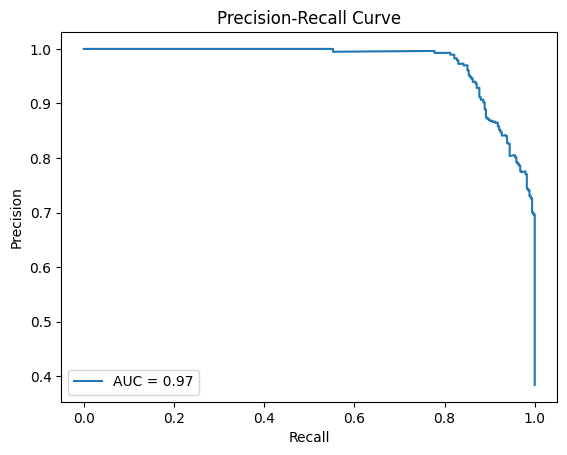

In [8]:
# Curva Precision-Recall

def plot_precision_recall(y_true, y_scores):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)
    
    plt.figure()
    plt.plot(recall, precision, label=f'AUC = {pr_auc:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    plt.show()

plot_precision_recall(y, y_pred_proba)

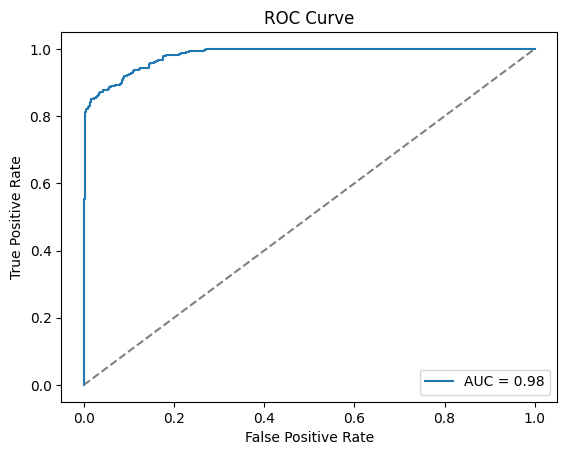

In [9]:
# Curva ROC

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()

plot_roc_curve(y, y_pred_proba)

In [10]:
# Generar el classification report
report = classification_report(y, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       549
           1       0.97      0.85      0.91       342

    accuracy                           0.93       891
   macro avg       0.94      0.92      0.93       891
weighted avg       0.94      0.93      0.93       891



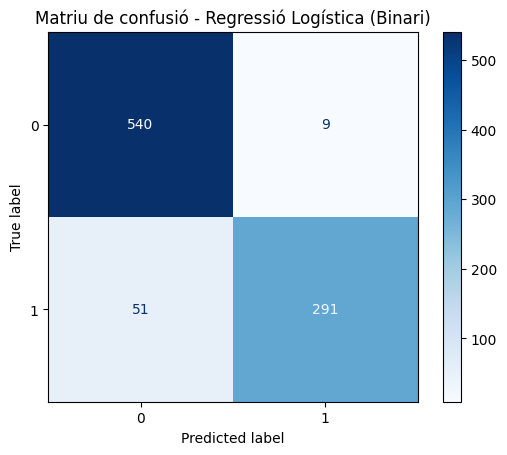

In [11]:
# Matriu de confusió
ConfusionMatrixDisplay.from_estimator(model, X, y, cmap=plt.cm.Blues)
plt.title("Matriu de confusió - Regressió Logística (Binari)")
plt.show()

### 4. Selecció de models amb validació creuada – **4 punts**

Fent servir la mètrica seleccionada a l’apartat anterior, cal escollir una sèrie de models i, mitjançant **validació creuada**, seleccionar el millor model amb els seus hiperparàmetres òptims, trobats a través d’una cerca (*hyperparameter search*).  

Aquesta tasca s’emmarca dins de l’aprenentatge computacional **supervisat**.  
A *scikit-learn* disposem de diverses tècniques ([documentació](https://scikit-learn.org/stable/supervised_learning.html)). A classe hem vist tècniques com:  
- Regressió logística  
- SVM amb diferents *kernels*  
- K-Nearest Neighbours (KNN)  
- Arbres de decisió  
- Random Forest  
- Gradient Boosting  

Per aquest apartat es demana seleccionar **un mínim de 4 models** (per exemple: regressió logística, random forest, KNN, SVM).  

**Preguntes:**  
-  Quins models heu considerat? Per què els heu seleccionat?  Hem considerat Regresió Logística, SVM, Random Forest, Gradient Boosting. Hem triat el model de Regresió Logística ja que és un model simple i lineal que ens pot servir com a baseline per la resta. Després, el SVM pot donar informació útil de la estructura de les dades si juguem amb el kernel. A part, és un model més complexe que el primer i pot arribar a demostrar resultats prometedors degut a la mida intermitja del dataset. Finalment, tant el Random Forest com el Gradient Boosting son exponents d'ensembles que poden ser interessants de comparar, a causa de les diferents estratègies d'ensamblatge.
-  Fent servir validació creuada, escolliu el millor model (amb hiperparàmetres per defecte). Amb hiperparàmetres per defecte, el millor model es el Gradient Boosting.
   -  Per què és important fer servir validació creuada?  Per reduir el biaix que pot sorgir a la separació entre el conjunt de validació i el d'entrenament.
   -  Heu de fer servir algun [tipus específic de validació creuada](https://scikit-learn.org/stable/modules/cross_validation.html)?  Si, hem de fer servir algún iterador amb estratificador. En aquest cas, hem fet servir StratifiedKFold, per reduir l'impacte de la diferència de proporció entre supervivents i no supervivents. D'aquesta manera, es manté la frecuència relativa de la classe en cada fold.
-  Seleccioneu un conjunt d’**hiperparàmetres** a provar per a cada model i realitzeu la cerca corresponent.  
   -  Hi ha algun model que es pugui descartar de primeres? Per què?
-  Mostreu els resultats en una taula amb: model, experiments realitzats, resultats (train i test) i, opcionalment, temps d’entrenament.  
-  Quin tipus de **K-fold** heu escollit per a la selecció de models i per a la selecció amb hiperparàmetres?  
   -  Com afecta el nombre de folds al resultat final?  
-  Quines formes de buscar el millor paràmetre heu trobat?  
   -  Són costoses computacionalment?  
   -  [Documentació *Grid Search*](https://scikit-learn.org/stable/modules/grid_search.html)  
   -  Quina heu seleccionat?  
-  Si disposem de recursos limitats (per exemple, un PC durant 1 hora), quin mètode creieu que donarà millor resultat final?  
-  Existeixen mètodes de cerca més eficients? ([scikit-optimize](https://scikit-optimize.github.io/stable/))  
-  Opcional: Configureu diferents mètodes de cerca per executar-se durant el mateix temps (0,5–1 h) amb el model i el mètode de cross-validation escollit.  
   -  Analitzeu quin ha arribat a una millor solució.  
   -  (Ajuda: estimeu el temps d’entrenament d’un model per trobar el número d’iteracions possibles.)  



In [12]:
#Treiem els Nans
df = fillNans("train.csv")

#Escalem els camps numèrics
scaler = RobustScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

#Dividim el dataset entre X i y
y = df[target]
X = df.drop(columns=[target, "Name", "Ticket", "Cabin", "PassengerId"])

#Passem els atributs categòrics a numèrics
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

#Fent servir validació creuada, escolliu el millor model (amb hiperparàmetres per defecte).  
models = {
    "Regressió Logística": LogisticRegression(random_state=42, max_iter=1000),
    "SVM": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='f1_macro')
    results[name] = {
        'mean_f1': cv_scores.mean(),
        'std_f1': cv_scores.std()
    }
    print(f"- {name}: F1-Score Mitjà = {cv_scores.mean():.4f} (std = {cv_scores.std():.4f})")

- Regressió Logística: F1-Score Mitjà = 0.7843 (std = 0.0279)
- SVM: F1-Score Mitjà = 0.8015 (std = 0.0258)
- Random Forest: F1-Score Mitjà = 0.7973 (std = 0.0238)
- Gradient Boosting: F1-Score Mitjà = 0.8159 (std = 0.0189)


In [ ]:
#Treiem els Nans
df = fillNans("train.csv")

#Escalem els camps numèrics
scaler = RobustScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

#Dividim el dataset entre X i y
y = df[target]
X = df.drop(columns=[target, "Name", "Ticket", "Cabin", "PassengerId"])

#Passem els atributs categòrics a numèrics
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

#escollim els hiperparametres que utilitzarem al grid search
models = {
    "Regressió Logística": (LogisticRegression(random_state=42, max_iter=10000,l1_ratio=0.5, solver='saga'),{
        'C':[0.01, 0.1, 1, 10, 100],
        'penalty':['l1','l2','elasticnet','none']
    }),

    "SVC": (SVC(random_state=42),{
        'C':[0.1,1,10,100],
        'kernel':['linear', 'rbf', 'poly', 'sigmoid']
    }),

    "Random Forest": (RandomForestClassifier(random_state=42),{
        'n_estimators':[100,200,500],
        'max_features':['sqrt','log2']
    }),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=42),{
        'n_estimators':[100,200,500],
        'learning_rate':[0.01,0.05,0.1]
    })
}

for nom, (model,parametres) in models.items():
    print(nom)
    grid = GridSearchCV(model, parametres, cv=5, scoring='f1_macro') #deberia de usar el StratifiedKFold en vez de poner 5?
    grid.fit(X, y)
    print(f"   Mejor score: {grid.best_score_:.4f}")
    print(f"   Mejores params: {grid.best_params_}\n")

Regressió Logística


c:\Users\jempa\Desktop\uni\apc\practicaAPC\titanico-1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
75 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\jempa\Desktop\uni\apc\practicaAPC\titanico-1\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\jempa\Desktop\uni\apc\practicaAPC\titanico-1\.venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Us

   Mejor score: 0.7779
   Mejores params: {'C': 10, 'penalty': 'l2'}

SVM
   Mejor score: 0.8103
   Mejores params: {'C': 10, 'kernel': 'rbf'}

Random Forest
   Mejor score: 0.7956
   Mejores params: {'max_features': 'sqrt', 'n_estimators': 100}

Gradient Boosting
   Mejor score: 0.8167
   Mejores params: {'learning_rate': 0.1, 'n_estimators': 500}



### 5. Anàlisi final – **1.5 punts**

Un cop seleccionat el millor model amb els hiperparàmetres òptims, cal elaborar un **report final** amb els resultats obtinguts.  

**Preguntes:**  
-  Mostreu les corbes ROC/PR (la que hàgiu escollit a l’apartat 3) i interpreteu els resultats.  
-  Analitzeu en detall les diferents mètriques que considereu adients.  
  -  Comentar breument com podríeu aplicar aquest model en un futur (cas d’ús).  
-  Quines possibles millores es podrien fer al vostre model?  